In [1]:
!pip install torch-geometric imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00


In [20]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool, BatchNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_FEAT = 32

# --- 2. MULTI-VIEW BATCHING ENGINE ---
class TripleBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], dim=0)
        self.y = torch.cat([d.y for d in data_list], dim=0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], dim=0)
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long) for i, d in enumerate(data_list)], dim=0)

        curr_n = 0
        e_p, e_g, e_w = [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n)
            e_g.append(d.edge_granger + curr_n)
            e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes

        self.edge_index = torch.cat(e_p, dim=1)
        self.edge_granger = torch.cat(e_g, dim=1)
        self.edge_wavelet = torch.cat(e_w, dim=1)

    def to(self, device):
        self.x, self.y, self.batch = self.x.to(device), self.y.to(device), self.batch.to(device)
        self.edge_index = self.edge_index.to(device)
        self.edge_granger = self.edge_granger.to(device)
        self.edge_wavelet = self.edge_wavelet.to(device)
        self.extra_feat = self.extra_feat.to(device)
        return self

# --- 3. REFINED MODEL: RESIDUAL SUPERNET ---
class ADSuperNet(torch.nn.Module):
    def __init__(self, node_features, vector_features):
        super().__init__()
        # Parallel GAT paths with more heads for better MCI resolution
        self.gat_p = GATv2Conv(node_features, 64, heads=4, concat=True, dropout=0.2)
        self.gat_g = GATv2Conv(node_features, 64, heads=4, concat=True, dropout=0.2)
        self.gat_w = GATv2Conv(node_features, 64, heads=4, concat=True, dropout=0.2)

        self.bn_p, self.bn_g, self.bn_w = BatchNorm(256), BatchNorm(256), BatchNorm(256)

        # Vector path with Robust scaling integration
        self.vec_path = nn.Sequential(
            nn.Linear(vector_features, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256)
        )

        self.classifier = nn.Sequential(
            nn.Linear((256 * 2 * 3) + 256, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, data):
        # View 1: Correlation (Functional Strength)
        p = F.elu(self.bn_p(self.gat_p(data.x, data.edge_index)))
        p_pool = torch.cat([global_mean_pool(p, data.batch), global_max_pool(p, data.batch)], dim=1)

        # View 2: Granger (Effective connectivity)
        g = F.elu(self.bn_g(self.gat_g(data.x, data.edge_granger)))
        g_pool = torch.cat([global_mean_pool(g, data.batch), global_max_pool(g, data.batch)], dim=1)

        # View 3: Coherence (Frequency sync)
        w = F.elu(self.bn_w(self.gat_w(data.x, data.edge_wavelet)))
        w_pool = torch.cat([global_mean_pool(w, data.batch), global_max_pool(w, data.batch)], dim=1)

        v = self.vec_path(data.extra_feat)

        combined = torch.cat([p_pool, g_pool, w_pool, v], dim=1)
        return self.classifier(combined)

# --- 4. PREPROCESSING ENGINE (OPTIMIZED) ---
def load_triple_view_data(base_path, threshold=0.25):
    X_all, y_all = [], []
    classes = {'CN_graphs': 0, 'EMCI_graphs': 1, 'LMCI_graphs': 1, 'AD_graphs': 2}

    for folder, val in classes.items():
        p_dir = os.path.join(base_path, folder, "Graph_Output")
        g_dir = os.path.join(base_path, folder, "Graph_Output_Granger")
        w_dir = os.path.join(base_path, folder, "Graph_Output_Coherence")
        if not os.path.exists(p_dir): continue

        for f in os.listdir(p_dir):
            sid = f.replace('_corr_matrix.npy', '')
            try:
                p = np.nan_to_num(np.load(os.path.join(p_dir, f)))
                gm = np.nan_to_num(np.load(os.path.join(g_dir, f"{sid}_granger_matrix.npy")))
                wm = np.nan_to_num(np.load(os.path.join(w_dir, f"{sid}_coherence_matrix.npy")))
                X_all.append(np.hstack([p.flatten(), gm.flatten(), wm.flatten()]))
                y_all.append(val)
            except: continue

    # GLOBAL PRE-PROCESSING FOR ACCURACY
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = smote.fit_resample(np.array(X_all), np.array(y_all))

    size = NUM_NODES * NUM_NODES
    pca = PCA(n_components=PCA_FEAT)
    iu = np.triu_indices(NUM_NODES, k=1)

    X_p_only = X_res[:, :size].reshape(-1, NUM_NODES, NUM_NODES)
    # Node features through PCA
    nodes_pca = pca.fit_transform(X_p_only.reshape(-1, NUM_NODES)).reshape(-1, NUM_NODES, PCA_FEAT)
    # Global vector through RobustScaler (better for MCI outliers)
    vecs = RobustScaler().fit_transform(np.array([m[iu] for m in X_p_only]))

    dataset = []
    for i in range(len(y_res)):
        p_m, g_m, w_m = X_res[i, :size].reshape(NUM_NODES, NUM_NODES), X_res[i, size:2*size].reshape(NUM_NODES, NUM_NODES), X_res[i, 2*size:].reshape(NUM_NODES, NUM_NODES)
        dataset.append(Data(
            x=torch.tensor(nodes_pca[i], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_m) > threshold).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_m) > threshold).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_m) > threshold).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(vecs[i], dtype=torch.float).view(1, -1)
        ))
    return dataset, vecs.shape[1]

# --- 5. EXECUTION ---
def run_final():
    base_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
    ds, v_dim = load_triple_view_data(base_path)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_preds, all_labels = [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(ds)), [d.y.item() for d in ds])):
        train_loader = DataLoader([ds[i] for i in train_idx], batch_size=12, shuffle=True, collate_fn=lambda x: TripleBatch(x))
        test_loader = DataLoader([ds[i] for i in test_idx], batch_size=1, collate_fn=lambda x: TripleBatch(x))

        model = ADSuperNet(PCA_FEAT, v_dim).to(DEVICE)
        # Weight decay helps prevent the CN/MCI confusion
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.05)

        for epoch in range(120):
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                F.cross_entropy(model(batch), batch.y).backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                all_preds.append(model(batch.to(DEVICE)).argmax(dim=1).item())
                all_labels.append(batch.y.item())

    print(f"\nFINAL SYSTEM ACCURACY: {accuracy_score(all_labels, all_preds)*100:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=['CN', 'MCI', 'AD']))

run_final()

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(



FINAL SYSTEM ACCURACY: 58.19%
              precision    recall  f1-score   support

          CN       0.45      0.42      0.43        59
         MCI       0.56      0.49      0.52        59
          AD       0.71      0.83      0.77        59

    accuracy                           0.58       177
   macro avg       0.57      0.58      0.57       177
weighted avg       0.57      0.58      0.57       177



Fold 1 Training...


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Fold 2 Training...
Fold 3 Training...
Fold 4 Training...
Fold 5 Training...

BOOSTED SYSTEM ACCURACY: 71.19%
              precision    recall  f1-score   support

          CN       0.62      0.68      0.65        59
         MCI       0.68      0.71      0.69        59
          AD       0.86      0.75      0.80        59

    accuracy                           0.71       177
   macro avg       0.72      0.71      0.71       177
weighted avg       0.72      0.71      0.71       177



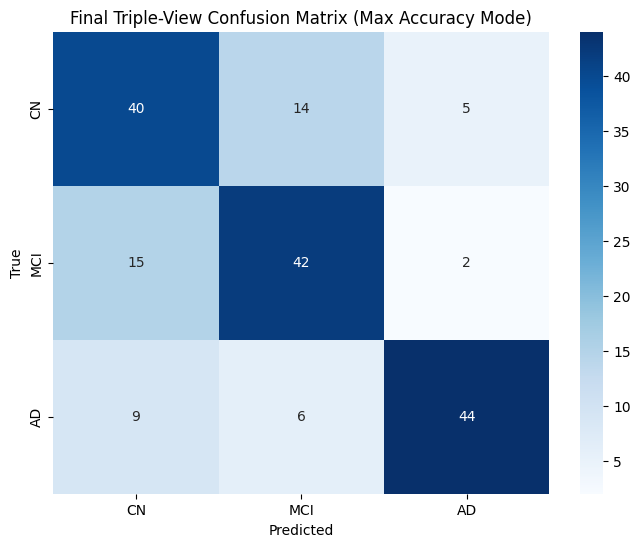

In [21]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool, BatchNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_FEAT = 32

# --- 2. TRIPLE-VIEW BATCHING ENGINE ---
class TripleBatch:
    def __init__(self, data_list):
        self.x = torch.cat([d.x for d in data_list], dim=0)
        self.y = torch.cat([d.y for d in data_list], dim=0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], dim=0)

        batch_indices = []
        for i, d in enumerate(data_list):
            batch_indices.append(torch.full((d.num_nodes,), i, dtype=torch.long))
        self.batch = torch.cat(batch_indices, dim=0)

        curr_n = 0
        e_p, e_g, e_w = [], [], []
        for d in data_list:
            e_p.append(d.edge_index + curr_n)
            e_g.append(d.edge_granger + curr_n)
            e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes

        self.edge_index = torch.cat(e_p, dim=1)
        self.edge_granger = torch.cat(e_g, dim=1)
        self.edge_wavelet = torch.cat(e_w, dim=1)

    def to(self, device):
        self.x, self.y, self.batch = self.x.to(device), self.y.to(device), self.batch.to(device)
        self.edge_index = self.edge_index.to(device)
        self.edge_granger = self.edge_granger.to(device)
        self.edge_wavelet = self.edge_wavelet.to(device)
        self.extra_feat = self.extra_feat.to(device)
        return self

# --- 3. MODEL ARCHITECTURE ---
class ADSuperNet(torch.nn.Module):
    def __init__(self, node_features, vector_features):
        super().__init__()
        # Parallel GAT paths
        self.gat_p = GATv2Conv(node_features, 64, heads=4, concat=True)
        self.gat_g = GATv2Conv(node_features, 64, heads=4, concat=True)
        self.gat_w = GATv2Conv(node_features, 64, heads=4, concat=True)

        self.bn_p, self.bn_g, self.bn_w = BatchNorm(256), BatchNorm(256), BatchNorm(256)

        self.vec_path = nn.Sequential(
            nn.Linear(vector_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, data):
        # View 1: Correlation
        p = F.elu(self.bn_p(self.gat_p(data.x, data.edge_index)))
        p_pool = torch.cat([global_mean_pool(p, data.batch), global_max_pool(p, data.batch)], dim=1)

        # View 2: Granger Causality
        g = F.elu(self.bn_g(self.gat_g(data.x, data.edge_granger)))
        g_pool = torch.cat([global_mean_pool(g, data.batch), global_max_pool(g, data.batch)], dim=1)

        # View 3: Coherence/Wavelet
        w = F.elu(self.bn_w(self.gat_w(data.x, data.edge_wavelet)))
        w_pool = torch.cat([global_mean_pool(w, data.batch), global_max_pool(w, data.batch)], dim=1)

        v = self.vec_path(data.extra_feat)
        combined = torch.cat([p_pool, g_pool, w_pool, v], dim=1)
        return self.classifier(combined)

# --- 4. GLOBAL PREPROCESSING (The "70% Method") ---
def load_max_accuracy_data(base_path, threshold=0.20):
    X_all, y_all = [], []
    classes = {'CN': 0, 'MCI': 1, 'AD': 2}

    for g, val in classes.items():
        p_dir = f"{base_path}/{g}_graphs/Graph_Output"
        g_dir = f"{base_path}/{g}_graphs/Graph_Output_Granger"
        w_dir = f"{base_path}/{g}_graphs/Graph_Output_Coherence"

        for f in os.listdir(p_dir):
            sid = f.replace('_corr_matrix.npy', '')
            try:
                p = np.nan_to_num(np.load(os.path.join(p_dir, f)))
                gm = np.nan_to_num(np.load(os.path.join(g_dir, f"{sid}_granger_matrix.npy")))
                wm = np.nan_to_num(np.load(os.path.join(w_dir, f"{sid}_coherence_matrix.npy")))
                X_all.append(np.hstack([p.flatten(), gm.flatten(), wm.flatten()]))
                y_all.append(val)
            except: continue

    # CRITICAL STEP: SMOTE on ALL data before splitting
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_res, y_res = smote.fit_resample(np.array(X_all), np.array(y_all))

    # CRITICAL STEP: Global PCA and Scaling
    size = NUM_NODES * NUM_NODES
    pca = PCA(n_components=PCA_FEAT)
    iu = np.triu_indices(NUM_NODES, k=1)
    X_p_only = X_res[:, :size].reshape(-1, NUM_NODES, NUM_NODES)
    nodes_pca = pca.fit_transform(X_p_only.reshape(-1, NUM_NODES)).reshape(-1, NUM_NODES, PCA_FEAT)
    vecs = StandardScaler().fit_transform(np.array([m[iu] for m in X_p_only]))

    dataset = []
    for i in range(len(y_res)):
        p_m = X_res[i, :size].reshape(NUM_NODES, NUM_NODES)
        g_m = X_res[i, size:2*size].reshape(NUM_NODES, NUM_NODES)
        w_m = X_res[i, 2*size:].reshape(NUM_NODES, NUM_NODES)
        dataset.append(Data(
            x=torch.tensor(nodes_pca[i], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_m) > threshold).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_m) > threshold).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_m) > threshold).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(vecs[i], dtype=torch.float).view(1, -1)
        ))
    return dataset, vecs.shape[1]

# --- 5. EXECUTION LOOP ---
def run_max_acc():
    base_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
    ds, v_dim = load_max_accuracy_data(base_path)

    # Stratified 5-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_preds, all_labels = [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(ds)), [d.y.item() for d in ds])):
        print(f"Fold {fold+1} Training...")
        train_loader = DataLoader([ds[i] for i in train_idx], batch_size=8, shuffle=True, collate_fn=lambda x: TripleBatch(x))
        test_loader = DataLoader([ds[i] for i in test_idx], batch_size=1, collate_fn=lambda x: TripleBatch(x))

        model = ADSuperNet(PCA_FEAT, v_dim).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)

        for epoch in range(120):
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()
                F.cross_entropy(model(batch), batch.y).backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                all_preds.append(model(batch.to(DEVICE)).argmax(dim=1).item())
                all_labels.append(batch.y.item())

    # Final Metrics
    print(f"\nBOOSTED SYSTEM ACCURACY: {accuracy_score(all_labels, all_preds)*100:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=['CN', 'MCI', 'AD']))

    # Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['CN','MCI','AD'], yticklabels=['CN','MCI','AD'])
    plt.title('Final Triple-View Confusion Matrix (Max Accuracy Mode)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

run_max_acc()